## 트랜스포머 번역기를 GPT 챗본으로 개조하자!

 질문과 답변을 연결하고, 정답을 한 토큰 뒤로 이동  
챗봇 Q/A를 `[BOS] Q [SEP] A [EOS]` 단일 토큰열로 구성. 전체 유효 구간의 다음 토큰 예측  
구조: Encoder(인코더)와 Cross-Attention(교차 어텐션)을 제거  
GPT 블록: 학습 가능한 위치 정보, 미래 가림, GELU, GPT-1의 정규화 순서를 적용  
causal self-attention만 유지. PAD Key와 미래 토큰 차단  
GPT-1의 Post-LN, GELU, 블록별 두 개 norm. 불필요한 final norm 제거  
프롬프트 전체 입력 → 마지막 위치에서 토큰 하나 선택 → 이어 붙이기  

In [234]:
import math
import random
import re
import unicodedata
from pathlib import Path

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

print("PyTorch:", torch.__version__)

PyTorch: 2.13.0


In [235]:
DATA_PATH = Path("/Users/yongza/300억/PRI_AI/AIFFEL_Self_Study/ChatbotData.csv")
TOKENIZER_NAME = "klue/bert-base"
SEED = 77 #42에서 변경
DEVICE = "auto"                
MAX_PAIRS = None                
MAX_LEN = 48
BATCH_SIZE = 64
EPOCHS = 10
RUN_TRAINING = True

VAL_RATIO = 0  
PATIENCE = 2     

N_LAYERS = 12
D_MODEL = 256
N_HEADS = 8
D_FF = 4 * D_MODEL
DROPOUT = 0.1
LEARNING_RATE = 0.0002
WARMUP_RATIO = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
print("실행 장치:", device)

실행 장치: mps


## 3. KLUE BERT 토크나이저로 글 조각과 ID 확인하기

`AutoTokenizer`는 지정한 이름에 맞는 도구를 불러옵니다. 
`[CLS]`를 BOS(시작)로, `[SEP]`를 질문 구분자와 EOS(종료)로 재사용합니다. 생성할 때는 질문 뒤 `[SEP]`까지 입력한 다음, **새로 예측한** `[SEP]`에서 멈춥니다. ID는 기존 SentencePiece의 `0, 1, 2, 3`을 복사하지 않고 토크나이저에서 읽습니다.


In [236]:
def preprocess_sentence(sentence):
    sentence = unicodedata.normalize("NFC", str(sentence))
    return re.sub(r"\s+", " ", sentence).strip()

raw_data = pd.read_csv(DATA_PATH)
data = raw_data[["Q", "A"]].dropna().copy()
for column in ["Q", "A"]:
    data[column] = data[column].map(preprocess_sentence)
data = data[(data["Q"] != "") & (data["A"] != "")]
data = data.drop_duplicates(subset=["Q", "A"])
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
if MAX_PAIRS is not None:
    data = data.head(MAX_PAIRS).copy()
print("원본 행 수:", len(raw_data), "| 이번 실습에 선택한 대화 수:", len(data))
display(data.head(3))

원본 행 수: 11823 | 이번 실습에 선택한 대화 수: 11750


,Q,A
0,비극.,인연이 거기까지인가봐요.
1,결혼이야기를 꺼내고 싶은데 어느 분위기에 꺼내는게 좋을까?,미래에 대해 이야기해보세요.
2,나 폰 중독인 거 같애,잠깐 핸드폰을 내려두세요.


In [237]:
# [변경 3] SentencePiece 학습 함수 대신 KLUE BERT 토크나이저 하나를 사용합니다.
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
PAD = tokenizer.pad_token_id
BOS = tokenizer.cls_token_id
EOS = tokenizer.sep_token_id
UNK = tokenizer.unk_token_id
VOCAB_SIZE = len(tokenizer)


print("단어장 크기:", VOCAB_SIZE)
print("PAD / BOS / EOS / UNK:", PAD, BOS, EOS, UNK)
text = "오늘은 기분이 좋아요!"
print("토큰:", tokenizer.tokenize(text))
print("ID:", tokenizer.encode(text, add_special_tokens=False))

단어장 크기: 32000
PAD / BOS / EOS / UNK: 0 2 3 1
토큰: ['오늘', '##은', '기분', '##이', '좋아', '##요', '!']
ID: [3822, 2073, 4754, 2052, 5723, 2182, 5]


## 4. 입력과 정답을 한 칸 어긋나게 만들기


 `[:-1]`은 마지막 하나를 빼고, `[1:]`은 첫 하나를 뺀다.

In [238]:
#  src/tgt 두 입력 대신, 대화 한 줄에서 input_ids/labels를 만듭니다.
def encode_dialogue(question, answer):
    q_ids = tokenizer.encode(question, add_special_tokens=False)
    a_ids = tokenizer.encode(answer, add_special_tokens=False)
    return [BOS] + q_ids + [EOS] + a_ids + [EOS]

sequences = []
kept_rows = []
for question, answer in data[["Q", "A"]].itertuples(index=False, name=None):
    ids = encode_dialogue(question, answer)
    # 한 칸 이동한 '입력'의 길이가 MAX_LEN 이하여야 합니다.
    if len(ids) <= MAX_LEN + 1:
        sequences.append(torch.tensor(ids, dtype=torch.long))
        kept_rows.append({"Q": question, "A": answer})

all_ids = pad_sequence(sequences, batch_first=True, padding_value=PAD)
input_ids = all_ids[:, :-1].contiguous()  #중요한 부분
labels = all_ids[:, 1:].contiguous()


# 같은 질문에 대한 여러 답변을 같은 세트에 배치
kept_df = pd.DataFrame(kept_rows)
if VAL_RATIO == 0:
    train_questions = kept_df["Q"].unique()
    val_questions = []
else:
    train_questions, val_questions = train_test_split(
        kept_df["Q"].unique(),
        test_size=VAL_RATIO,
        random_state=SEED,
    )

train_idx = kept_df.index[kept_df["Q"].isin(train_questions)].tolist()
val_idx = kept_df.index[kept_df["Q"].isin(val_questions)].tolist()

dataset = TensorDataset(input_ids, labels)

train_loader = DataLoader(
    Subset(dataset, train_idx),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
)

val_loader = None

if len(val_idx) > 0:
    val_loader = DataLoader(
        Subset(dataset, val_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

print(f"Train: {len(train_idx):,} | Validation: {len(val_idx):,}")
print("길이 초과 제외:", len(data) - len(sequences))


Train: 11,745 | Validation: 0
길이 초과 제외: 5


In [239]:
# 바로 위에서 만든 첫 대화의 '읽는 조각 → 맞혀야 할 조각'을 확인합니다.
length = len(sequences[0]) - 1
preview = pd.DataFrame({
    "위치": list(range(length)),
    "입력 ID": input_ids[0, :length].tolist(),
    "읽는 토큰": tokenizer.convert_ids_to_tokens(input_ids[0, :length].tolist()),
    "정답 ID": labels[0, :length].tolist(),
    "다음 토큰 정답": tokenizer.convert_ids_to_tokens(labels[0, :length].tolist()),
})
display(pd.DataFrame(kept_rows[:1]))
display(preview)
print("입력/정답 이동 검사 통과")

,Q,A
0,비극.,인연이 거기까지인가봐요.


,위치,입력 ID,읽는 토큰,정답 ID,다음 토큰 정답
0,0,2,[CLS],8018,비극
1,1,8018,비극,18,.
2,2,18,.,3,[SEP]
3,3,3,[SEP],6984,인연
4,4,6984,인연,2052,##이
5,5,2052,##이,4370,거기
6,6,4370,거기,2299,##까
7,7,2299,##까,2118,##지
8,8,2118,##지,2179,##인
9,9,2179,##인,2116,##가


입력/정답 이동 검사 통과


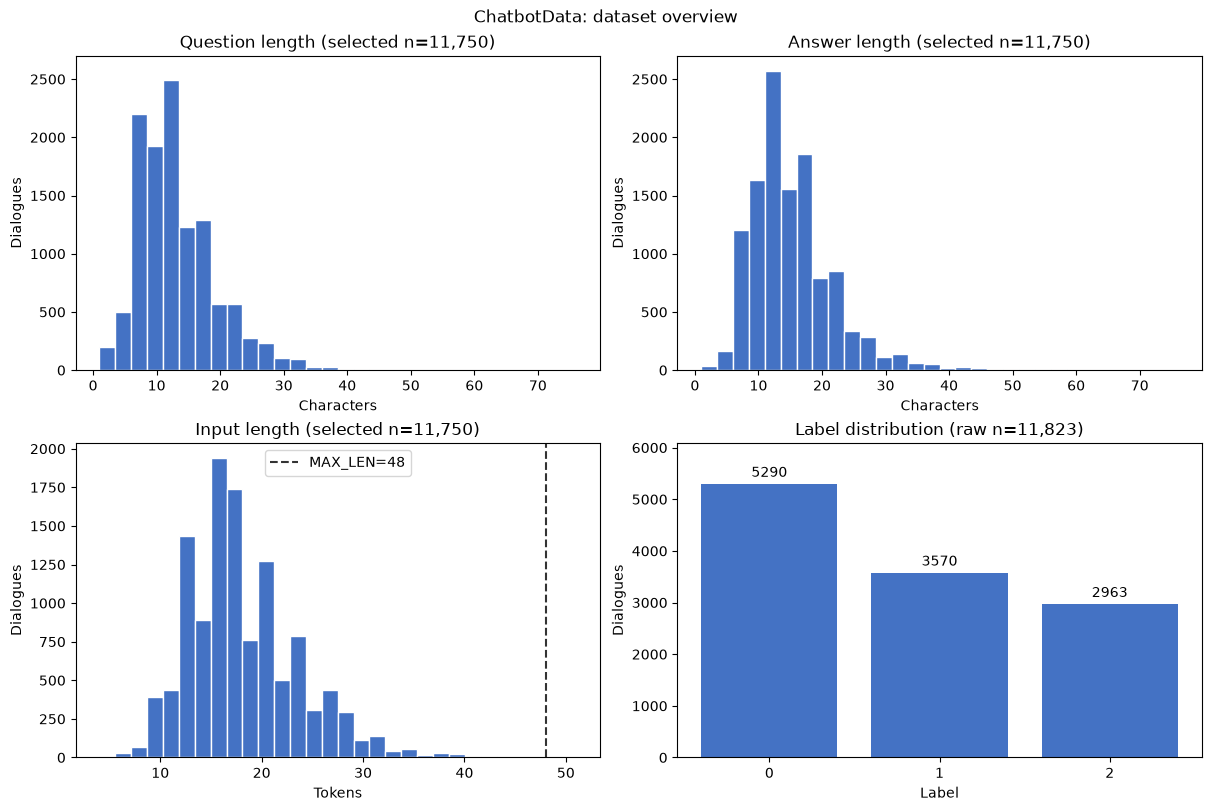

,Q_chars,A_chars,input_tokens
count,11750.0,11750.0,11750.0
mean,12.9,15.0,18.1
std,6.2,6.7,5.5
min,1.0,1.0,4.0
50%,12.0,14.0,17.0
90%,21.0,23.0,26.0
95%,25.0,27.0,28.0
99%,32.0,37.0,34.0
max,56.0,76.0,51.0


길이 초과 제외: 5/11,750개 (0.04%)


,Q,A,input_tokens
3455,오늘 만나기로 했는데 빈손으로 나가?,준비하지 않아도 상관 없다고 생각해요. 필요하다면 화려하지 않고 부담 없는 선물을 ...,51
6343,썸 탈 때 연락문제로 속상한 적 있어?,썸 탈 때는 특히 속상한 것 같아요. 내 맘 같지 않고 아직 내 사람이 아니니까요....,51
2072,썸남이랑 1박 2일로 펜셥 잡고 놀러가는데 고백 없으면 끝?,고백을 안하고 사귀는 경우도 있지만 정확하게 물어보는게 좋아요. 먼저 얘기를 끄내보세요.,50
5896,5년 사귄 여자친구와 이별이네. 조언부탁좀 드려,저는 저에게 투자하는 시간을 가져요. 예를들면 운동이나 여행같이 잡념을 없앨 수 있...,50
11594,오래 연애해서 그런가 관심이 줄었어,연애하다보면 서로에게 익숙해져서 처음만큼 관심을 갖지 않게 되는 게 사실일 거예요....,49


In [240]:
import matplotlib.pyplot as plt
import numpy as np

eda = data.copy()
eda["Q_chars"] = eda["Q"].str.len()
eda["A_chars"] = eda["A"].str.len()
eda["input_tokens"] = [
    len(encode_dialogue(q, a)) - 1  # 특수 토큰과 입력/정답 한 칸 이동 반영
    for q, a in eda[["Q", "A"]].itertuples(index=False, name=None)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("ChatbotData: dataset overview")

# 1~2. 질문과 답변의 글자 수 분포: 같은 구간과 축으로 비교
bins = np.histogram_bin_edges(
    np.concatenate([eda["Q_chars"], eda["A_chars"]]), bins=30
)
axes[0, 1].sharex(axes[0, 0])
axes[0, 1].sharey(axes[0, 0])

for ax, col, title in zip(
    axes[0],
    ["Q_chars", "A_chars"],
    ["Question length", "Answer length"],
):
    ax.hist(eda[col], bins=bins, color="#4472C4", edgecolor="white")
    ax.set(title=f"{title} (selected n={len(eda):,})", xlabel="Characters")

# 3. 길이 제한을 적용하기 전의 모델 입력 토큰 수
axes[1, 0].hist(
    eda["input_tokens"], bins=30, color="#4472C4", edgecolor="white"
)
axes[1, 0].axvline(
    MAX_LEN, color="#333333", linestyle="--", label=f"MAX_LEN={MAX_LEN}"
)
axes[1, 0].set(
    title=f"Input length (selected n={len(eda):,})", xlabel="Tokens"
)
axes[1, 0].legend()

# 4. 원본 CSV의 라벨별 개수
counts = raw_data["label"].value_counts().sort_index()
bars = axes[1, 1].bar(
    counts.index.astype(str), counts.values, color="#4472C4"
)
axes[1, 1].bar_label(bars, padding=3)
axes[1, 1].set(
    title=f"Label distribution (raw n={len(raw_data):,})",
    xlabel="Label",
    ylim=(0, counts.max() * 1.15),
)

for ax in axes.flat:
    ax.set_ylabel("Dialogues")

plt.show()

# 요약 통계
cols = ["Q_chars", "A_chars", "input_tokens"]
display(
    eda[cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1)
)

# 길이 제한으로 제외되는 비율
excluded = eda["input_tokens"] > MAX_LEN
print(
    f"길이 초과 제외: {excluded.sum():,}/{len(eda):,}개 "
    f"({excluded.mean():.2%})"
)

# 가장 긴 대화 5개를 직접 확인
display(eda.nlargest(5, "input_tokens")[["Q", "A", "input_tokens"]])

## 5. 미래 토큰을 가리기

Padding mask(빈칸 가림표)는 PAD를 참고하지 못하게 합니다.  
`1`은 가리는 칸, `0`은 읽을 수 있는 칸. 


In [241]:
def generate_padding_mask(tokens):
    return (tokens == PAD)[:, None, None, :]  # [묶음, 1, 1, 읽을 위치]

def generate_masks(tokens):
    length = tokens.size(1)
    future_mask = torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=tokens.device),
        diagonal=1,
    )
    return generate_padding_mask(tokens) | future_mask

demo = torch.tensor([[BOS, UNK, EOS, PAD]], dtype=torch.long)
print("행=현재 위치, 열=참고하려는 위치 / 1=가림")
print(generate_masks(demo)[0, 0].int())

행=현재 위치, 열=참고하려는 위치 / 1=가림
tensor([[0, 1, 1, 1],
        [0, 0, 1, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1]], dtype=torch.int32)


## 6. 기존 MultiHeadAttention 이어 쓰기


In [242]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        # 논문의 attention dropout을 추가
        self.attention_dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        return x.reshape(x.size(0), x.size(1), self.num_heads, self.depth).transpose(1, 2)

    def forward(self, query, key, value, mask):
        q = self.split_heads(self.W_q(query))
        k = self.split_heads(self.W_k(key))
        v = self.split_heads(self.W_v(value))
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        scores = scores.masked_fill(mask, float("-inf"))
        attention = torch.softmax(scores, dim=-1)
        out = torch.matmul(self.attention_dropout(attention), v)
        out = out.transpose(1, 2).contiguous().reshape(query.size(0), query.size(1), -1)
        return self.linear(out), attention

## 7. Encoder 삭제와 DecoderLayer를 GPTBlock으로 바꾸기

기존 `DecoderLayer`의 `cross_attention`, `memory`, `src_mask`가 사라집니다. FFN은 각 토큰이 가진 정보를 한 번 더 가공합니다. 

  GPT-1 순서인 '가공 → 더하기 → 정규화' 입니다. 

In [243]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        # [변경 7] ReLU → GPT-1 공개 코드와 같은 tanh 근사의 GELU.
        self.activation = nn.GELU(approximate="tanh")
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class GPTBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-5)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-5)
        self.dropout = nn.Dropout(dropout)
        # [변경 8] cross_attention과 세 번째 LayerNorm은 제거합니다.

    def forward(self, x, mask):
        out, attention = self.self_attention(x, x, x, mask)
        # GPT-1: 연산 결과에 입력을 더한 뒤 정규화합니다 (Post-LN).
        x = self.norm1(x + self.dropout(out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x, attention

## 8. 토큰 정보 + 위치 정보 → GPT 조립



- `token_embedding`: 각 글 조각을 표현하는 숫자 목록입니다.
- `position_embedding`: 0번, 1번… 각 자리를 표현하는 숫자 목록입니다. 이것도 학습하면서 바뀝니다.
- `lm_head`: 각 위치에서 '다음 토큰 후보별 점수'를 냅니다. 입력 단어장과 같은 가중치를 공유합니다.


이 기본값에서 입력 `[2, 10]`은 '문장 2개, 각각 10개 토큰'입니다. 임베딩 후 `[2, 10, 128]`, 출력은 `[2, 10, 단어장 크기]`입니다. 출력에 바로 Softmax를 넣지 않는 이유는 `CrossEntropyLoss`가 그 계산을 포함하기 때문입니다.

In [244]:
class GPT(nn.Module):
    def __init__(self, vocab_size, max_len, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.max_len = max_len
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            GPTBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init_weights)
        # 기존 decoder embedding 공유를 단일 GPT embedding 공유로 연결.
        self.lm_head.weight = self.token_embedding.weight
        # Encoder, Cross-Attention, 마지막 별도 LayerNorm은 없습니다.

    def _init_weights(self, layer):
        if isinstance(layer, (nn.Linear, nn.Embedding)):
            nn.init.normal_(layer.weight, mean=0.0, std=0.02)
            if isinstance(layer, nn.Linear) and layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def embedding(self, tokens):
        length = tokens.size(1)
        if not 1 <= length <= self.max_len:
            raise ValueError(f"입력 길이는 1~{self.max_len} 토큰이어야 합니다.")
        positions = torch.arange(length, device=tokens.device).unsqueeze(0)
        # [변경 12] 토큰 표현 + 자리 표현. 기존 sqrt(d_model) 배율은 제거.
        return self.dropout(self.token_embedding(tokens) + self.position_embedding(positions))

    def forward(self, tokens, return_attention=False):
        x = self.embedding(tokens)
        mask = generate_masks(tokens)
        attentions = []
        for block in self.blocks:
            x, attention = block(x, mask)
            if return_attention:
                attentions.append(attention.detach())
        logits = self.lm_head(x)
        if return_attention:
            return logits, attentions
        return logits

MODEL_CONFIG = dict(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, n_layers=N_LAYERS,
                    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, dropout=DROPOUT)

In [245]:
# 질문·답변 전체의 다음 토큰을 채점합니다. PAD만 제외합니다.
loss_object = nn.CrossEntropyLoss(ignore_index=PAD)

def build_optimizer(model):
    decay, no_decay = [], []
    for parameter in model.parameters():
        (decay if parameter.ndim >= 2 else no_decay).append(parameter)
    return torch.optim.AdamW([
        {"params": decay, "weight_decay": 0.01},
        {"params": no_decay, "weight_decay": 0.0},
    ], lr=LEARNING_RATE, betas=(0.9, 0.999), eps=1e-8)

def make_lr_schedule(total_steps):
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
    def lr_scale(step):
        # step=0부터 첫 업데이트가 가능하도록 작은 양의 학습률로 시작합니다.
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))
    return lr_scale

def train_step(x, y, model, optimizer):
    model.train()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad(set_to_none=True)
    # 기존 model(src, dec_in) → model(x).
    logits = model(x)
    loss = loss_object(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
    assert torch.isfinite(loss), "손실이 정상적인 숫자인지 확인하세요."
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), int((y != PAD).sum().item())

In [246]:
@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)

        loss = loss_object(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1),
        )

        token_count = int((y != PAD).sum().item())
        total_loss += loss.item() * token_count
        total_tokens += token_count

    return total_loss / total_tokens

In [247]:
history = []
use_validation = val_loader is not None

if RUN_TRAINING:
    optimizer = build_optimizer(model)
    total_steps = EPOCHS * len(train_loader)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_schedule(total_steps)
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        total_loss, total_tokens = 0.0, 0

        for batch_index, (x, y) in enumerate(train_loader, start=1):
            loss, token_count = train_step(x, y, model, optimizer)
            scheduler.step()

            total_loss += loss * token_count
            total_tokens += token_count

            if batch_index % 20 == 0:
                print(
                    f"epoch {epoch}: "
                    f"{batch_index}/{len(train_loader)} batch 완료"
                )

        train_loss = total_loss / total_tokens

        # 검증을 사용할 때만 검증 손실 계산
        val_loss = (
            evaluate_loss(model, val_loader)
            if use_validation else None
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "tokens": total_tokens,
        })

        message = f"epoch {epoch}/{EPOCHS} | train {train_loss:.4f}"
        if use_validation:
            message += f" | val {val_loss:.4f}"
        print(message)

        # 검증을 사용할 때만 최적 가중치 보관과 조기 종료
        if use_validation:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch

                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                bad_epochs = 0

            else:
                bad_epochs += 1

                if bad_epochs >= PATIENCE:
                    print(
                        f"Early stopping: "
                        f"{PATIENCE}회 연속 검증 손실 개선 없음"
                    )
                    break

    if use_validation and best_state is not None:
        model.load_state_dict(best_state)
        print(
            f"최적 가중치 복원: epoch {best_epoch}, "
            f"val loss {best_val_loss:.4f}"
        )
    else:
        print("검증 생략: 마지막 에포크의 가중치를 사용합니다.")

    model.eval()
    display(pd.DataFrame(history))

else:
    print("RUN_TRAINING=False: 학습을 건너뜁니다.")

epoch 1: 20/184 batch 완료
epoch 1: 40/184 batch 완료
epoch 1: 60/184 batch 완료
epoch 1: 80/184 batch 완료
epoch 1: 100/184 batch 완료
epoch 1: 120/184 batch 완료
epoch 1: 140/184 batch 완료
epoch 1: 160/184 batch 완료
epoch 1: 180/184 batch 완료
epoch 1/10 | train 2.2282
epoch 2: 20/184 batch 완료
epoch 2: 40/184 batch 완료
epoch 2: 60/184 batch 완료
epoch 2: 80/184 batch 완료
epoch 2: 100/184 batch 완료
epoch 2: 120/184 batch 완료
epoch 2: 140/184 batch 완료
epoch 2: 160/184 batch 완료
epoch 2: 180/184 batch 완료
epoch 2/10 | train 2.2608
epoch 3: 20/184 batch 완료
epoch 3: 40/184 batch 완료
epoch 3: 60/184 batch 완료
epoch 3: 80/184 batch 완료
epoch 3: 100/184 batch 완료
epoch 3: 120/184 batch 완료
epoch 3: 140/184 batch 완료
epoch 3: 160/184 batch 완료
epoch 3: 180/184 batch 완료
epoch 3/10 | train 2.1791
epoch 4: 20/184 batch 완료
epoch 4: 40/184 batch 완료
epoch 4: 60/184 batch 완료
epoch 4: 80/184 batch 완료
epoch 4: 100/184 batch 완료
epoch 4: 120/184 batch 완료
epoch 4: 140/184 batch 완료
epoch 4: 160/184 batch 완료
epoch 4: 180/184 batch 완료
ep

,epoch,train_loss,val_loss,tokens
0,1,2.228215,None,212751
1,2,2.260778,None,212751
2,3,2.179061,None,212751
3,4,2.086261,None,212751
4,5,1.990556,None,212751
5,6,1.907772,None,212751
6,7,1.831036,None,212751
7,8,1.775817,None,212751
8,9,1.739240,None,212751
9,10,1.718808,None,212751


## 10. 질문을 넣고 한 토큰씩 답변 이어 쓰기

입력으로 `[CLS] 질문 [SEP]`을 넣습니다. 마지막 위치의 점수에서 가장 높은 토큰을 하나 골라 붙이고 다시 입력합니다. 이것이 Greedy decoding(가장 높은 점수 선택)입니다. 새로 생성한 `[SEP]`가 나오거나, 정한 생성 길이에 도달하면 멈춥니다.

`[PAD]`, `[CLS]`, `[MASK]`, `[UNK]` 같은 특수 토큰은 출력 후보에서 제외하고 종료 토큰 `[SEP]`는 허용합니다. 문장 품질은 학습량에 따라 달라집니다. 

In [248]:
# translate/encode/decode 대신, 같은 GPT에 글을 계속 이어 넣습니다.
@torch.no_grad()
def generate(question, model, max_new_tokens=30):
    model.eval()
    question = preprocess_sentence(question)
    if not question:
        raise ValueError("질문을 한 글자 이상 입력하세요.")
    if max_new_tokens < 1:
        raise ValueError("max_new_tokens는 1 이상이어야 합니다.")
    prompt = [BOS] + tokenizer.encode(question, add_special_tokens=False) + [EOS]
    if len(prompt) > model.max_len:
        raise ValueError(f"질문이 너무 깁니다. 시작·구분자를 포함해 {model.max_len} 토큰 이하로 줄이세요.")
    generated = []
    stop_reason = "생성 길이 제한"
    model_device = next(model.parameters()).device
    blocked = sorted(set(tokenizer.all_special_ids) - {EOS})
    for _ in range(max_new_tokens):
        context = prompt + generated
        if len(context) > model.max_len:
            stop_reason = "모델 입력 길이 제한"
            break
        tokens = torch.tensor([context], dtype=torch.long, device=model_device)
        scores = model(tokens)[0, -1].clone()
        scores[blocked] = float("-inf")
        next_id = int(scores.argmax().item())
        generated.append(next_id)
        if next_id == EOS:
            stop_reason = "EOS 생성"
            break
    return {
        "질문": question,
        "생성 답변": tokenizer.decode(generated, skip_special_tokens=True),
        "생성 토큰": tokenizer.convert_ids_to_tokens(generated),
    }

In [249]:
MY_QUESTIONS = ["오늘 너무 힘들었어", "주말에 뭐 하지?", "너는 누구야?", "진짜 너무 어렵다.", "진짜 하나도 모르겠어, 어쩌지?", "공부가 너무 어렵다. 도와줘."]
results = [generate(question, model) for question in MY_QUESTIONS]
display(pd.DataFrame(results))
print("입력에 따른 토큰 생성 동작 확인 완료")
print("실제 답변 품질과 학습 여부는 위 출력 및 학습 로그를 함께 확인하세요.")

,질문,생성 답변,생성 토큰
0,오늘 너무 힘들었어,지금은 괜찮아졌길 바랄게요.,"[지금, ##은, 괜찮, ##아졌, ##길, 바랄, ##게요, ., [SEP]]"
1,주말에 뭐 하지?,같이 놀고 싶은 시간이죠.,"[같이, 놀, ##고, 싶, ##은, 시간, ##이, ##죠, ., [SEP]]"
2,너는 누구야?,저는 위로해드리는 로봇이에요.,"[저, ##는, 위로, ##해, ##드리, ##는, 로봇, ##이, ##에, ##요..."
3,진짜 너무 어렵다.,많이 힘들었겠어요.,"[많이, 힘들, ##었, ##겠, ##어요, ., [SEP]]"
4,"진짜 하나도 모르겠어, 어쩌지?",당신의 삶을 응원해드리세요.,"[당신, ##의, 삶, ##을, 응원, ##해, ##드리, ##세요, ., [SEP]]"
5,공부가 너무 어렵다. 도와줘.,지금처럼 잘하는 게 좋을 거예요.,"[지금, ##처럼, 잘, ##하, ##는, 게, 좋, ##을, 거, ##예, ##요..."


입력에 따른 토큰 생성 동작 확인 완료
실제 답변 품질과 학습 여부는 위 출력 및 학습 로그를 함께 확인하세요.


### 발리데이연 셋 없이  10에포크로 최초 실행.
 

| 질문 | 생성 답변 | 생성 ID | 생성 토큰 | 종료 이유 |   |
| --- | --- | --- | --- | --- | --- |
| 0 | 오늘 너무 힘들었어 | 저도요. | [1535, 2119, 2182, 18, 3] | [저, ##도, ##요, ., [SEP]] | EOS 생성 |
| 1 | 주말에 뭘 하면 좋을까? | 마음에 따라 다르겠죠. | [3717, 2170, 3653, 4405, 2918, 2321, 18, 3] | [마음, ##에, 따라, 다르, ##겠, ##죠, ., [SEP]] | EOS 생성 |
| 2 | 너는 누구야? | 저는 마음이 필요하죠. | [1535, 2259, 3717, 2052, 3677, 2205, 2321, 18, 3] | [저, ##는, 마음, ##이, 필요, ##하, ##죠, ., [SEP]] | EOS 생성 |
| 3 | 공부는 왜 어려워? | 잘할 수 있을 거예요. | [1521, 2085, 1295, 1513, 2069, 568, 2194, 2182... | [잘, ##할, 수, 있, ##을, 거, ##예, ##요, ., [SEP]] | EOS 생성 |


### 발리데이션 셋을 나눈후 얼리 스탑을 진행
 1) 0.2 일때 16에포크에서 얼리스탑. 정성적 답변 품질 저하
 2) 0.1 로 비율을 낮춰 다시 실행. 정성적 답변 품질 저하. 

### 데이터 셋 분리 없이 다시 15에포크 학습

| 질문 | 생성 답변 | 생성 ID | 생성 토큰 | 종료 이유 |   |
| --- | --- | --- | --- | --- | --- |
| 0 | 오늘 너무 힘들었어 | 저도요. | [1535, 2119, 2182, 18, 3] | [저, ##도, ##요, ., [SEP]] | EOS 생성 |
| 1 | 주말에 뭘 하면 좋을까? | 잘할 수 있을 거예요. | [1521, 2085, 1295, 1513, 2069, 568, 2194, 2182... | [잘, ##할, 수, 있, ##을, 거, ##예, ##요, ., [SEP]] | EOS 생성 |
| 2 | 너는 누구야? | 저는 위로해주세요. | [1535, 2259, 7587, 2097, 2223, 5971, 18, 3] | [저, ##는, 위로, ##해, ##주, ##세요, ., [SEP]] | EOS 생성 |
| 3 | 공부는 왜 어려워? | 공부는 중요한 것이에요. | [4244, 2259, 3748, 2470, 575, 2052, 2170, 2182... | [공부, ##는, 중요, ##한, 것, ##이, ##에, ##요, ., [SEP]] | EOS 생성 |



### 7에포크로 축소 실행

| 질문 | 생성 답변 | 생성 ID | 생성 토큰 | 종료 이유 |   |
| --- | --- | --- | --- | --- | --- |
| 0 | 오늘 너무 힘들었어 | 저도요. | [1535, 2119, 2182, 18, 3] | [저, ##도, ##요, ., [SEP]] | EOS 생성 |
| 1 | 주말에 뭘 하면 좋을까? | 마음이 더 힘들 거예요. | [3717, 2052, 831, 4390, 568, 2194, 2182, 18, 3] | [마음, ##이, 더, 힘들, 거, ##예, ##요, ., [SEP]] | EOS 생성 |
| 2 | 너는 누구야? | 저는 좋은 사람이에요. | [1535, 2259, 1560, 2073, 3611, 2052, 2170, 218... | [저, ##는, 좋, ##은, 사람, ##이, ##에, ##요, ., [SEP]] | EOS 생성 |
| 3 | 공부는 왜 어려워? | 잘할 수 있을 거예요. | [1521, 2085, 1295, 1513, 2069, 568, 2194, 2182... | [잘, ##할, 수, 있, ##을, 거, ##예, ##요, ., [SEP]] | EOS 생성 |


 1) 데이터셋이 작아서 그런지 학습회차가 늘어난다고 정성적인 결과가 좋아지지 않았다. 
 2) 데이터 증강 작업을 해보고 싶다. 


| 질문 | 생성 답변 | 생성 ID | 생성 토큰 | 종료 이유 |   |
| --- | --- | --- | --- | --- | --- |
| 0 | 오늘 너무 힘들었어 | 저도요. | [1535, 2119, 2182, 18, 3] | [저, ##도, ##요, ., [SEP]] | EOS 생성 |
| 1 | 주말에 뭘 하면 좋을까? | 좋은 사람이네요. | [1560, 2073, 3611, 2052, 2203, 2182, 18, 3] | [좋, ##은, 사람, ##이, ##네, ##요, ., [SEP]] | EOS 생성 |
| 2 | 너는 누구야? | 저는 위로해보세요. | [1535, 2259, 7587, 2097, 2178, 5971, 18, 3] | [저, ##는, 위로, ##해, ##보, ##세요, ., [SEP]] | EOS 생성 |
| 3 | 공부는 왜 어려워? | 공부는 안 좋은 거예요. | [4244, 2259, 1378, 1560, 2073, 568, 2194, 2182... | [공부, ##는, 안, 좋, ##은, 거, ##예, ##요, ., [SEP]] | EOS 생성 |
| 4 | 와 진짜 하나도 모르겠다 | 잘 될 거예요. | [1521, 861, 568, 2194, 2182, 18, 3] | [잘, 될, 거, ##예, ##요, ., [SEP]] | EOS 생성 |
| 5 | 좀 살려주라 | 저도요! | [1535, 2119, 2182, 5, 3] | [저, ##도, ##요, !, [SEP]] | EOS 생성 |


## 시드를 42에서 77로 바꿨다. 
77이 행운의 숫자였다. 

| 질문 | 생성 답변 | 생성 토큰 |   |
| --- | --- | --- | --- |
| 0 | 오늘 너무 힘들었어 | 지금은 괜찮아졌길 바랄게요. | [지금, ##은, 괜찮, ##아졌, ##길, 바랄, ##게요, ., [SEP]] |
| 1 | 주말에 뭐 하지? | 같이 놀고 싶은 시간이죠. | [같이, 놀, ##고, 싶, ##은, 시간, ##이, ##죠, ., [SEP]] |
| 2 | 너는 누구야? | 저는 위로해드리는 로봇이에요. | [저, ##는, 위로, ##해, ##드리, ##는, 로봇, ##이, ##에, ##요... |
| 3 | 진짜 너무 어렵다. | 많이 힘들었겠어요. | [많이, 힘들, ##었, ##겠, ##어요, ., [SEP]] |
| 4 | 진짜 하나도 모르겠어, 어쩌지? | 당신의 삶을 응원해드리세요. | [당신, ##의, 삶, ##을, 응원, ##해, ##드리, ##세요, ., [SEP]] |
| 5 | 공부가 너무 어렵다. 도와줘. | 지금처럼 잘하는 게 좋을 거예요. | [지금, ##처럼, 잘, ##하, ##는, 게, 좋, ##을, 거, ##예, ##요... |
